### Input Layer

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\arhip\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\arhip\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Accuracy for vector_size=50: 0.9342
Accuracy for vector_size=100: 0.9438
Accuracy for vector_size=150: 0.9463
Accuracy for vector_size=200: 0.9459
Accuracy for vector_size=250: 0.9486
Accuracy for vector_size=300: 0.9485
Accuracy for vector_size=350: 0.9470
Accuracy for vector_size=400: 0.9476
Accuracy for vector_size=450: 0.9469
Accuracy for vector_size=500: 0.9484


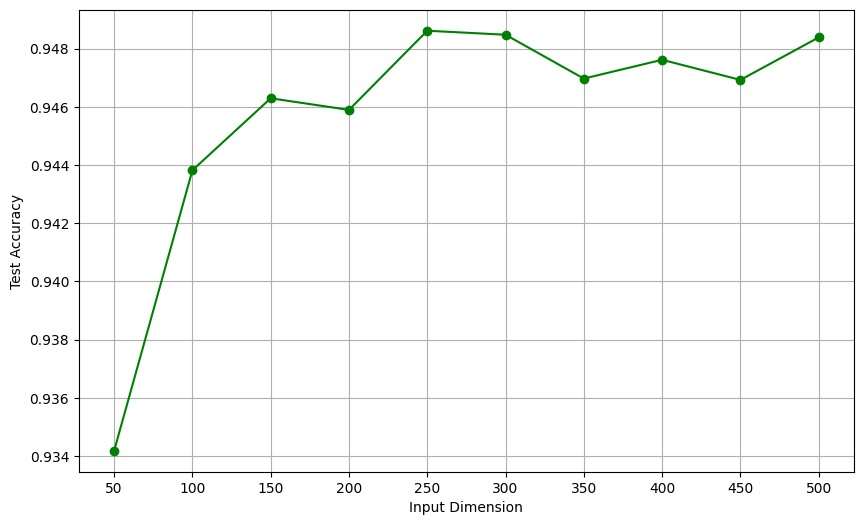

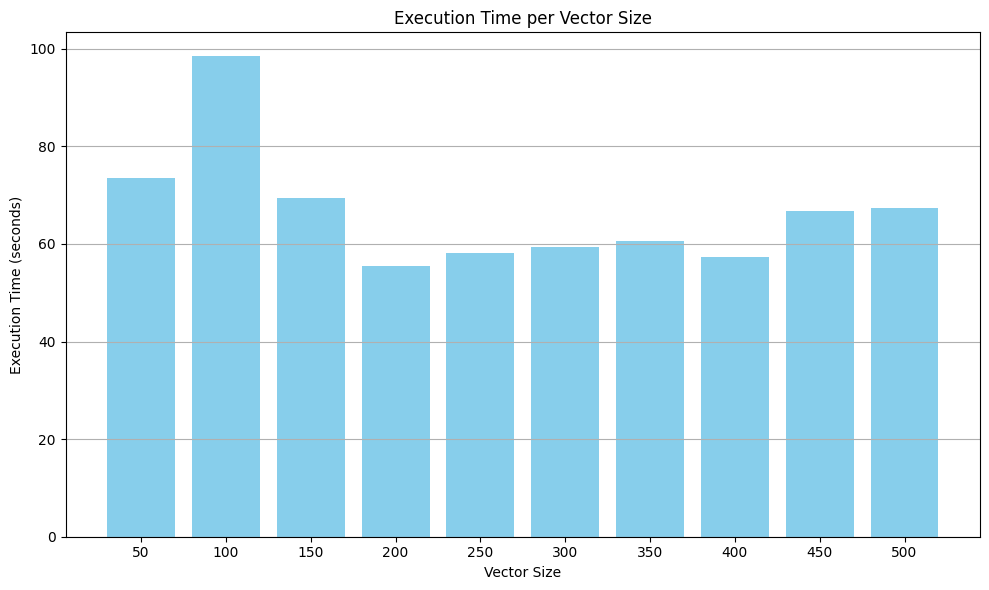

In [2]:
import pandas as pd
import numpy as np
import nltk
import re
import torch
import torch.nn as nn
import torch.optim as optim
import time
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

nltk.download('punkt')
nltk.download('stopwords')

df = pd.read_csv("../data/train.csv")
df = df.dropna(subset=['text', 'class'])

stop_words = set(stopwords.words("catalan"))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r"[^\w\s]", '', text)
    tokens = word_tokenize(text, language='spanish')  # close to Catalan
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    return tokens

df['tokens'] = df['text'].apply(preprocess)

le = LabelEncoder()
y = le.fit_transform(df['class'])
num_classes = len(np.unique(y))

vector_sizes = list(range(50, 501, 50))
accuracies = []
times = []

for vector_size in vector_sizes:
    start_time = time.time()

    w2v_model = Word2Vec(sentences=df['tokens'], vector_size=vector_size, window=5, min_count=3, workers=4, epochs=20)

    def get_doc_vector(tokens):
        vecs = [w2v_model.wv[t] for t in tokens if t in w2v_model.wv]
        return np.mean(vecs, axis=0) if vecs else np.zeros(w2v_model.vector_size)

    df['doc_vec'] = df['tokens'].apply(get_doc_vector)
    X = np.vstack(df['doc_vec'].values)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32)

    class TextClassifier(nn.Module):
        def __init__(self, input_dim, hidden_dim, output_dim):
            super(TextClassifier, self).__init__()
            self.fc1 = nn.Linear(input_dim, hidden_dim)
            self.relu = nn.ReLU()
            self.dropout = nn.Dropout(0.3)
            self.fc2 = nn.Linear(hidden_dim, output_dim)

        def forward(self, x):
            out = self.fc1(x)
            out = self.relu(out)
            out = self.dropout(out)
            return self.fc2(out)

    model = TextClassifier(input_dim=vector_size, hidden_dim=64, output_dim=num_classes)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(5):  # Use fewer epochs for speed
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            preds = model(xb)
            _, predicted = torch.max(preds, 1)
            correct += (predicted == yb).sum().item()
            total += yb.size(0)

    acc = correct / total
    elapsed_time = time.time() - start_time
    print(f"Accuracy for vector_size={vector_size}: {acc:.4f}")
    accuracies.append(acc)
    times.append(elapsed_time)
    
# Plotting
plt.figure(figsize=(10, 6))
plt.plot(vector_sizes, accuracies, marker='o', linestyle='-', color='green')
plt.xlabel("Input Dimension")
plt.ylabel("Test Accuracy")
plt.grid(True)
plt.xticks(vector_sizes)
plt.show()

plt.figure(figsize=(10, 6))
plt.bar([str(v) for v in vector_sizes], times, color='skyblue')
plt.xlabel("Vector Size")
plt.ylabel("Execution Time (seconds)")
plt.title("Execution Time per Vector Size")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### Dropout

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\arhip\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\arhip\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Accuracy for vector_size=500: 0.9478
Accuracy for vector_size=500: 0.9460
Accuracy for vector_size=500: 0.9453
Accuracy for vector_size=500: 0.9443
Accuracy for vector_size=500: 0.9413
Accuracy for vector_size=500: 0.9376
Accuracy for vector_size=500: 0.9319
Accuracy for vector_size=500: 0.9215
Accuracy for vector_size=500: 0.8840


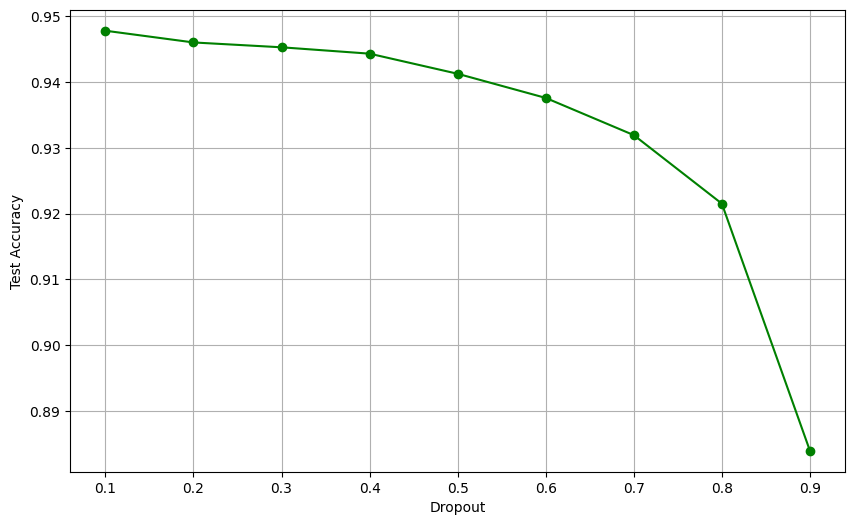

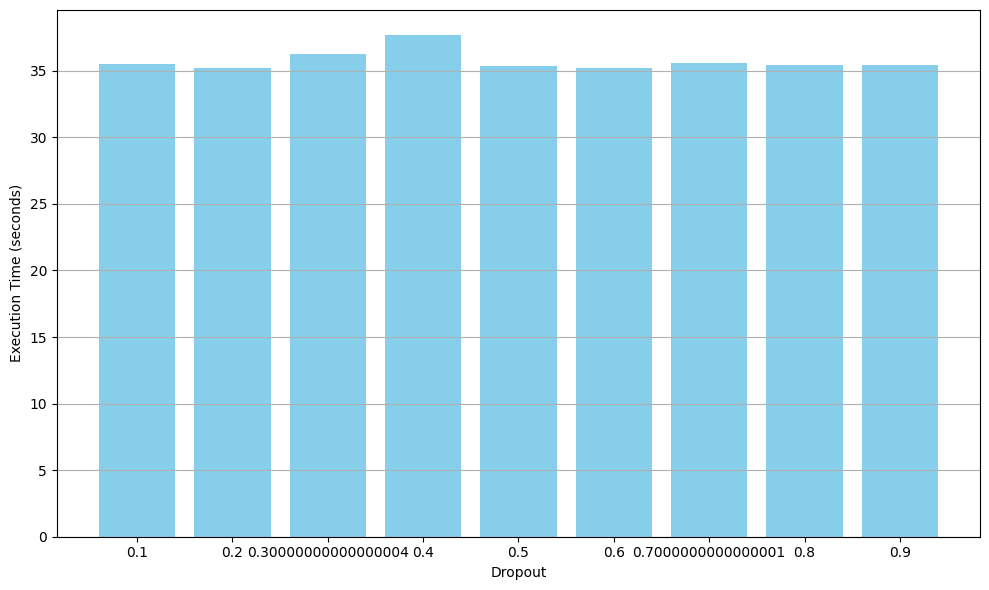

In [3]:
import pandas as pd
import numpy as np
import nltk
import re
import torch
import torch.nn as nn
import torch.optim as optim
import time
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

nltk.download('punkt')
nltk.download('stopwords')

df = pd.read_csv("../data/train.csv")
df = df.dropna(subset=['text', 'class'])

stop_words = set(stopwords.words("catalan"))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r"[^\w\s]", '', text)
    tokens = word_tokenize(text, language='spanish')  # close to Catalan
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    return tokens

df['tokens'] = df['text'].apply(preprocess)

le = LabelEncoder()
y = le.fit_transform(df['class'])
num_classes = len(np.unique(y))

dropout = np.arange(0.1, 1.0, 0.1)
accuracies = []
times = []

for dropped in dropout:
    start_time = time.time()
    
    w2v_model = Word2Vec(sentences=df['tokens'], vector_size=250, window=5, min_count=3, workers=4, epochs=20)

    def get_doc_vector(tokens):
        vecs = [w2v_model.wv[t] for t in tokens if t in w2v_model.wv]
        return np.mean(vecs, axis=0) if vecs else np.zeros(w2v_model.vector_size)

    df['doc_vec'] = df['tokens'].apply(get_doc_vector)
    X = np.vstack(df['doc_vec'].values)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32)

    class TextClassifier(nn.Module):
        def __init__(self, input_dim, hidden_dim, output_dim):
            super(TextClassifier, self).__init__()
            self.fc1 = nn.Linear(input_dim, hidden_dim)
            self.relu = nn.ReLU()
            self.dropout = nn.Dropout(dropped)
            self.fc2 = nn.Linear(hidden_dim, output_dim)

        def forward(self, x):
            out = self.fc1(x)
            out = self.relu(out)
            out = self.dropout(out)
            return self.fc2(out)

    model = TextClassifier(input_dim=250, hidden_dim=64, output_dim=num_classes)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(5):  # Using fewer epochs for speed
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            preds = model(xb)
            _, predicted = torch.max(preds, 1)
            correct += (predicted == yb).sum().item()
            total += yb.size(0)

    acc = correct / total
    elapsed_time = time.time() - start_time
    print(f"Accuracy for dropout={dropped}: {acc:.4f}")
    accuracies.append(acc)
    times.append(elapsed_time)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(dropout, accuracies, marker='o', linestyle='-', color='green')
plt.xlabel("Dropout")
plt.ylabel("Test Accuracy")
plt.grid(True)
plt.xticks(dropout)
plt.show()

plt.figure(figsize=(10, 6))
plt.bar([str(v) for v in dropout], times, color='skyblue')
plt.xlabel("Dropout")
plt.ylabel("Execution Time (seconds)")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


### Hidden Dim

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\arhip\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\arhip\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Accuracy for hidden dimension=2: 0.5883
Accuracy for hidden dimension=4: 0.7811
Accuracy for hidden dimension=8: 0.8893
Accuracy for hidden dimension=16: 0.9275
Accuracy for hidden dimension=32: 0.9408
Accuracy for hidden dimension=64: 0.9475
Accuracy for hidden dimension=128: 0.9511
Accuracy for hidden dimension=256: 0.9530


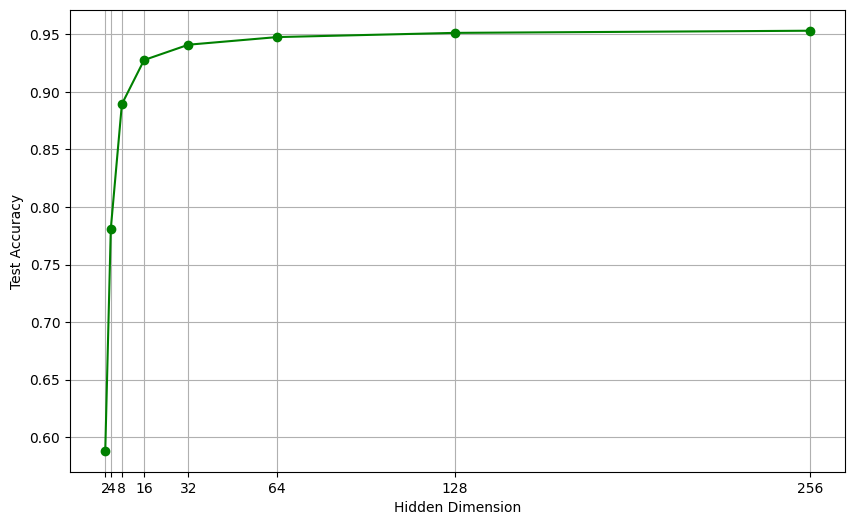

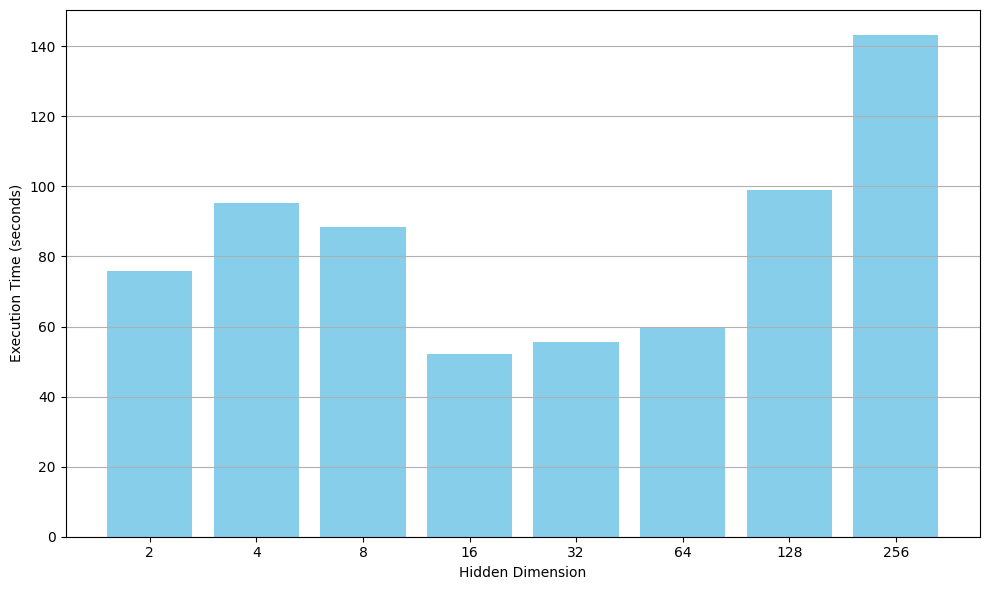

In [5]:
import pandas as pd
import numpy as np
import nltk
import re
import torch
import torch.nn as nn
import torch.optim as optim
import time
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

nltk.download('punkt')
nltk.download('stopwords')

df = pd.read_csv("../data/train.csv")
df = df.dropna(subset=['text', 'class'])

stop_words = set(stopwords.words("catalan"))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r"[^\w\s]", '', text)
    tokens = word_tokenize(text, language='spanish')  # close to Catalan
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    return tokens

df['tokens'] = df['text'].apply(preprocess)

le = LabelEncoder()
y = le.fit_transform(df['class'])
num_classes = len(np.unique(y))

hidden_dimensions = [2**i for i in range(1, 9)]
accuracies = []
times = []

for hidden_dimension in hidden_dimensions:
    start_time = time.time()
    
    w2v_model = Word2Vec(sentences=df['tokens'], vector_size=250, window=5, min_count=3, workers=4, epochs=20)

    def get_doc_vector(tokens):
        vecs = [w2v_model.wv[t] for t in tokens if t in w2v_model.wv]
        return np.mean(vecs, axis=0) if vecs else np.zeros(w2v_model.vector_size)

    df['doc_vec'] = df['tokens'].apply(get_doc_vector)
    X = np.vstack(df['doc_vec'].values)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32)

    class TextClassifier(nn.Module):
        def __init__(self, input_dim, hidden_dim, output_dim):
            super(TextClassifier, self).__init__()
            self.fc1 = nn.Linear(input_dim, hidden_dim)
            self.relu = nn.ReLU()
            self.dropout = nn.Dropout(0.3)
            self.fc2 = nn.Linear(hidden_dim, output_dim)

        def forward(self, x):
            out = self.fc1(x)
            out = self.relu(out)
            out = self.dropout(out)
            return self.fc2(out)

    model = TextClassifier(input_dim=250, hidden_dim=hidden_dimension, output_dim=num_classes)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(10):  # Use fewer epochs for speed
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            preds = model(xb)
            _, predicted = torch.max(preds, 1)
            correct += (predicted == yb).sum().item()
            total += yb.size(0)

    acc = correct / total
    elapsed_time = time.time() - start_time
    print(f"Accuracy for hidden dimension={hidden_dimension}: {acc:.4f}")
    accuracies.append(acc)
    times.append(elapsed_time)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(hidden_dimensions, accuracies, marker='o', linestyle='-', color='green')
plt.xlabel("Hidden Dimension")
plt.ylabel("Test Accuracy")
plt.grid(True)
plt.xticks(hidden_dimensions)
plt.show()

plt.figure(figsize=(10, 6))
plt.bar([str(v) for v in hidden_dimensions], times, color='skyblue')
plt.xlabel("Hidden Dimension")
plt.ylabel("Execution Time (seconds)")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


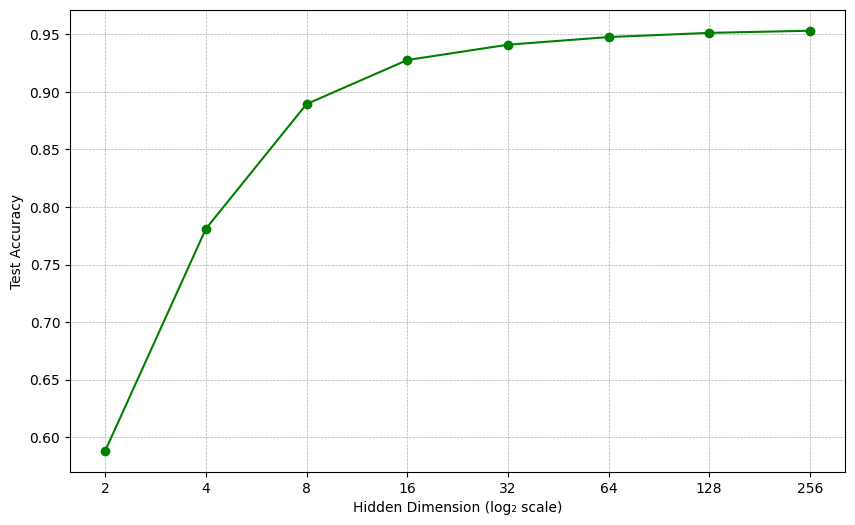

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(hidden_dimensions, accuracies, marker='o', linestyle='-', color='green')
plt.xlabel("Hidden Dimension (log₂ scale)")
plt.ylabel("Test Accuracy")
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.xscale("log", base=2)
plt.xticks(hidden_dimensions, labels=[str(hd) for hd in hidden_dimensions])
plt.show()

### Epochs

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\arhip\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\arhip\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Accuracy for epoch dimension=5: 0.9515
Accuracy for epoch dimension=10: 0.9529
Accuracy for epoch dimension=15: 0.9537
Accuracy for epoch dimension=20: 0.9535
Accuracy for epoch dimension=25: 0.9532
Accuracy for epoch dimension=30: 0.9553


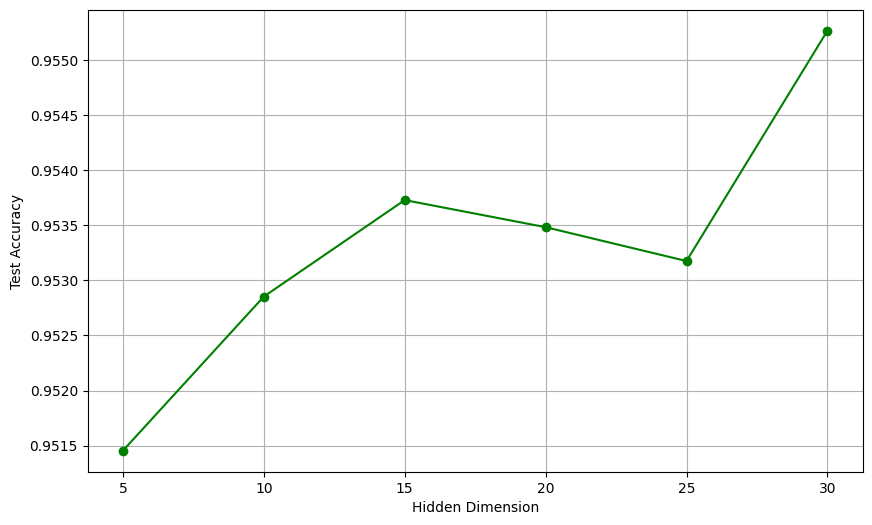

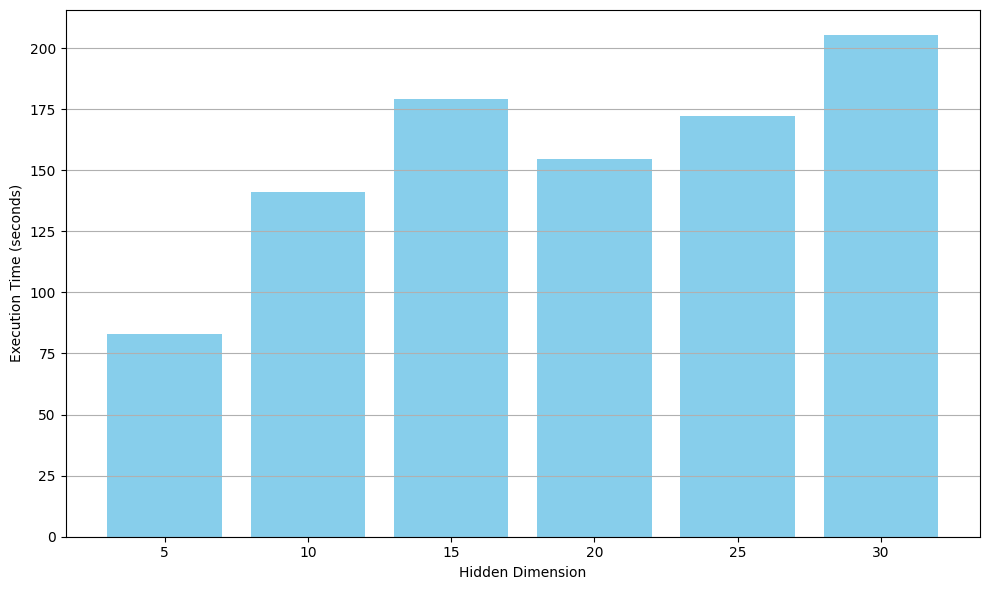

In [ ]:
import pandas as pd
import numpy as np
import nltk
import re
import torch
import torch.nn as nn
import torch.optim as optim
import time
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

nltk.download('punkt')
nltk.download('stopwords')

df = pd.read_csv("../data/train.csv")
df = df.dropna(subset=['text', 'class'])

stop_words = set(stopwords.words("catalan"))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r"[^\w\s]", '', text)
    tokens = word_tokenize(text, language='spanish')  # close to Catalan
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    return tokens

df['tokens'] = df['text'].apply(preprocess)

le = LabelEncoder()
y = le.fit_transform(df['class'])
num_classes = len(np.unique(y))

epoch_array = list(range(5, 31, 5))
accuracies = []
times = []

for pval in epoch_array:
    start_time = time.time()
    
    w2v_model = Word2Vec(sentences=df['tokens'], vector_size=250, window=5, min_count=3, workers=4, epochs=20)

    def get_doc_vector(tokens):
        vecs = [w2v_model.wv[t] for t in tokens if t in w2v_model.wv]
        return np.mean(vecs, axis=0) if vecs else np.zeros(w2v_model.vector_size)

    df['doc_vec'] = df['tokens'].apply(get_doc_vector)
    X = np.vstack(df['doc_vec'].values)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32)

    class TextClassifier(nn.Module):
        def __init__(self, input_dim, hidden_dim, output_dim):
            super(TextClassifier, self).__init__()
            self.fc1 = nn.Linear(input_dim, hidden_dim)
            self.relu = nn.ReLU()
            self.dropout = nn.Dropout(0.3)
            self.fc2 = nn.Linear(hidden_dim, output_dim)

        def forward(self, x):
            out = self.fc1(x)
            out = self.relu(out)
            out = self.dropout(out)
            return self.fc2(out)

    model = TextClassifier(input_dim=250, hidden_dim=64, output_dim=num_classes)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(pval):  # Use fewer epochs for speed
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            preds = model(xb)
            _, predicted = torch.max(preds, 1)
            correct += (predicted == yb).sum().item()
            total += yb.size(0)

    acc = correct / total
    elapsed_time = time.time() - start_time
    print(f"Accuracy for epoch dimension={pval}: {acc:.4f}")
    accuracies.append(acc)
    times.append(elapsed_time)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(epoch_array, accuracies, marker='o', linestyle='-', color='green')
plt.xlabel("Hidden Dimension")
plt.ylabel("Test Accuracy")
plt.grid(True)
plt.xticks(epoch_array)
plt.show()

plt.figure(figsize=(10, 6))
plt.bar([str(v) for v in epoch_array], times, color='skyblue')
plt.xlabel("Hidden Dimension")
plt.ylabel("Execution Time (seconds)")
plt.grid(axis='y')
plt.tight_layout()
plt.show()
